In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None) 
import seaborn as sns
import plotly.express as px

In [72]:
df= pd.read_csv('3.1_dataset_clean.csv')
df

,link,address,apartment_name,sector,price,price_sqft,super_area,bedrooms,bathroom,balcony,additional_rooms,age_possession,floor,floor_num,total_floors,furnishing_type,facing,num_parking,features,servant_room,study_room,pooja_room,store_room,luxury_score,luxury_category,parking
0,https://www.99acres.com/2-bhk-bedroom-apartmen...,"Bharat Residency\nJharsa, Gurgaon",bharat residency,jharsa,0.70,5477.3,1278.0000,2,2,2,Store Room,1 to 5 year old,Ground of 4 Floors,0,4,Semifurnished,na,1 Open,"['Security / Fire Alarm', 'Lift(s)', 'High Cei...",0,0,0,1,21,medium,1
1,https://www.99acres.com/2-bhk-bedroom-apartmen...,"GLS Arawali Homes\nSohna, Gurgaon",gls arawali homes,sohna,0.38,5569.0,682.3526,2,2,2,Others,1 to 5 year old,6th of 13 Floors,6,13,Semifurnished,East,"1 Covered, 1 Open","['Security / Fire Alarm', 'Power Back-up', 'Fe...",0,0,0,0,35,medium,2
2,https://www.99acres.com/2-bhk-bedroom-apartmen...,"CHD Avenue 71\nSector 71, Gurgaon",chd avenue 71,sector 71,1.35,11268.8,1198.0000,2,2,2,NaN,10+ year old,1st of 14 Floors,1,14,Unfurnished,North,1 Covered,"['Centrally Air Conditioned', 'Water purifier'...",0,0,0,0,71,high,1
3,https://www.99acres.com/4-bhk-bedroom-apartmen...,"signature avenue\nSector 82, Gurgaon",signature avenue,sector 82,3.40,94444.4,360.0000,4,4,2,"Pooja Room,Servant Room",0 to 1 year old,4th of 4 Floors,4,4,Furnished,North-East,2 Covered,"['Power Back-up', 'Lift(s)', 'Water purifier',...",1,0,1,0,28,medium,2
4,https://www.99acres.com/2-bhk-bedroom-apartmen...,"Signature Global Park\nSohna, Gurgaon",signature global park,sohna,0.95,8920.2,1065.0000,2,2,2,NaN,0 to 1 year old,1st of 4 Floors,1,4,Semifurnished,na,1 Covered,"['Lift(s)', 'Swimming Pool', 'Park', 'Fitness ...",0,0,0,0,18,low,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5588,https://www.99acres.com/4-bhk-bedroom-apartmen...,"MVN Athens\nSohna, Gurgaon",mvn athens,sohna,0.88,6699.7,1313.5000,4,4,2,NaN,5 to 10 year old,11st of 14 Floors,11,14,Semifurnished,North,2 Open,"['Security / Fire Alarm', 'Lift(s)', 'Maintena...",0,0,0,0,26,medium,2
5589,https://www.99acres.com/4-bhk-bedroom-apartmen...,"Pareena Express Heights\nSector 99, Gurgaon",pareena express heights,sector 99,3.75,10714.3,3500.0000,4,4,3+,"Servant Room,Study Room",1 to 5 year old,14th of 14 Floors,14,14,Unfurnished,North-East,2 Covered,"['Water purifier', 'Centrally Air Conditioned'...",1,1,0,0,64,high,2
5590,https://www.99acres.com/3-bhk-bedroom-apartmen...,"Sare Homes\nSector 92, Gurgaon",sare homes,sector 92,1.45,8906.6,1628.0000,3,4,3+,Servant Room,1 to 5 year old,11st of 19 Floors,11,19,Semifurnished,South-East,1 Covered,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1,0,0,0,49,medium,1
5591,https://www.99acres.com/3-bhk-bedroom-apartmen...,"M3M Heights\nSector 65, Gurgaon",m3m heights,sector 65,3.85,13199.9,2916.6800,3,3,2,NaN,0 to 1 year old,22nd of 34 Floors,22,34,Semifurnished,North,NaN,"['Power Back-up', 'Security / Fire Alarm', 'In...",0,0,0,0,36,medium,0


### Correcting rows with incorrect super_area and price_sqft column

In [73]:
#finding links having outliers in price_sqft and super_area
problem_links = df[(df['super_area']<800)  & (df['price_sqft']>14000)].sort_values('price_sqft',ascending=False)['link'].to_list()

In [74]:
#### Rescraping problem links

# import undetected_chromedriver as uc
# from selenium.webdriver.common.by import By
# import time
# import pandas as pd
# import numpy as np

# #Load links from file

# # Set up Chrome
# options = uc.ChromeOptions()
# options.add_argument("--disable-blink-features=AutomationControlled")
# options.add_argument("--incognito")
# driver = uc.Chrome(options=options)

# # df = pd.DataFrame(columns = ['address','price','super_area'])
# temp_df = pd.DataFrame(columns = ['link','price','super_area' , 'area_units'])

# count = 0
# for i in range(0,len(problem_links)):
#     count+=1
#     print(f"Scraping {problem_links[i]}")
#     print('link number',count)

#     details = {}
#     details['link'] = problem_links[i]

#     try:
#         driver.get(problem_links[i])
#         time.sleep(3)  # allow page to load

#         #extract price
#         try:
#             details['price'] = driver.find_element(by = By.XPATH , value = '//*[@id="pdPrice"]').text.strip()
#         except Exception as e:
#             print('Unable to extract price -> error ', e)
#             details['price'] = np.nan
        
#         #super area
#         try:
#             details['super_area'] = driver.find_element(by = By.XPATH , value = '//*[@id="superbuiltupArea_span"]').text.strip()

#         except Exception as e:
#             try:    #if carpet area is given
#                 details['super_area'] = float(driver.find_element(by = By.XPATH , value = '//*[@id="carpetArea_span"]').text.strip())*1.42
#                 print('scaped carpet area')
#             except Exception as e:
#                 try:    #if built up area is given
                    
#                     details['super_area'] = float(driver.find_element(by = By.XPATH , value = '//*[@id="builtupArea_span"]').text.strip())*1.25
#                     print('scaped built up area')
#                 except Exception as e:
#                     print('Unable to extract area -> error ', e)
#                     details['super_area'] = np.nan
        
#         try:
#              details['area_units'] = driver.find_element(by = By.XPATH, value = '//*[@id="factArea"]/a/span').text.strip()
#         except:
#             print('unable to find the correct units')
#             details['area_units'] = np.nan
                
#         #create dataframe
#         temp_df = pd.concat([temp_df,pd.DataFrame([details])],ignore_index= True)

#     except Exception as e:
#         print(f"❌ Error scraping {problem_links[i]}: {e}")


# temp_df.to_csv('4.2_problem_links.csv',index=False)
# driver.quit()


In [75]:
temp_df = pd.read_csv('4.2_problem_links.csv')
temp_df.shape

(78, 4)

In [76]:
temp_df.dropna(how = 'any', inplace=True)
temp_df.shape

(77, 4)

In [77]:
temp_df['area_units'].unique()

array(['sq.m.', 'sq.yards', 'sq.ft.'], dtype=object)

In [78]:
def transform_area(row):
    if 'sq.m.' in row['area_units']:
        row['super_area'] = float(row['super_area'])*10.76
    elif 'sq.yards' in row['area_units']:
        row['super_area'] = float(row['super_area'])*9
    return row

temp_df = temp_df.apply(transform_area,axis=1)

In [79]:
#replace values 
# Create mapping from df2
super_area_map = dict(zip(temp_df['link'], temp_df['super_area']))

# Replace only if link matches
df['super_area'] = df['link'].map(super_area_map).fillna(df['super_area'])

In [80]:
price_sqft = round(df['price']*10000000/df['super_area'],1)
df['price_sqft'] = price_sqft

In [81]:
df['super_area'].describe()

count     5593.000000
mean      2067.599339
std        905.360197
min         99.400000
25%       1550.000000
50%       1930.000000
75%       2410.000000
max      10000.000000
Name: super_area, dtype: float64

<Axes: ylabel='price_sqft'>

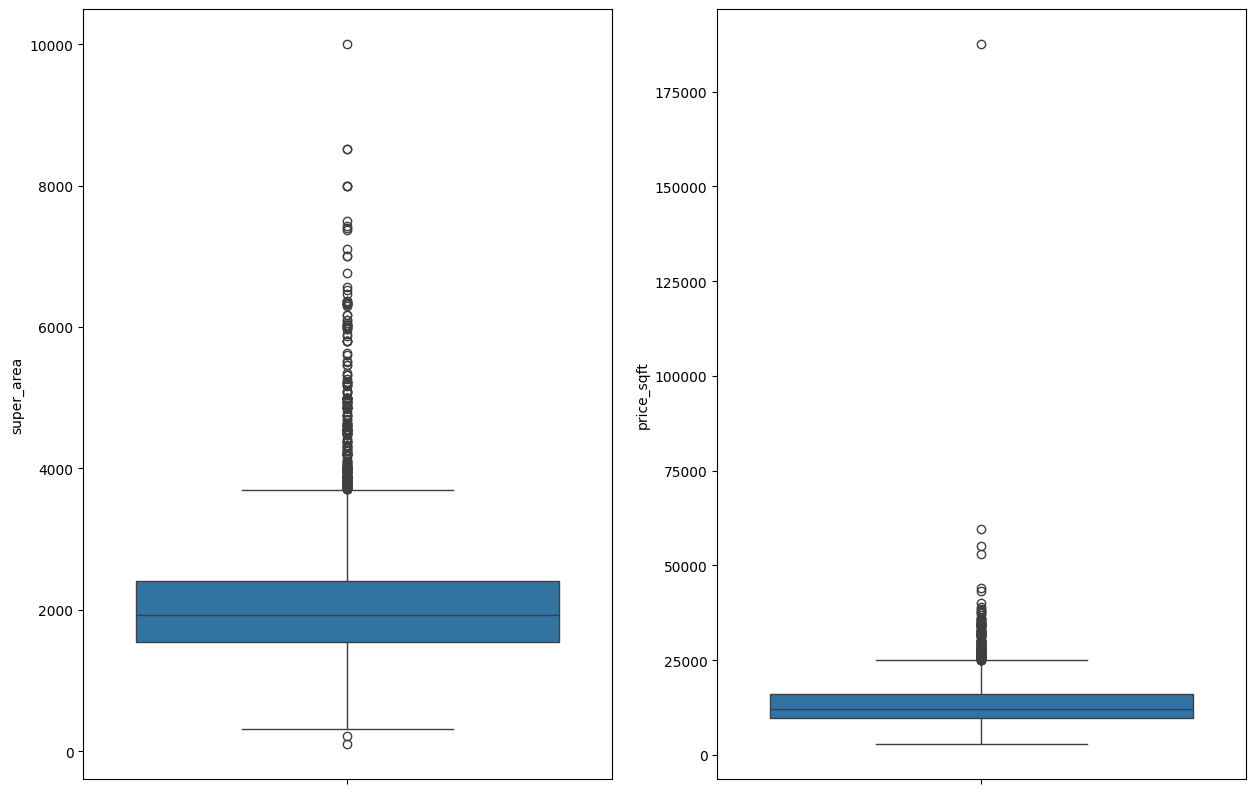

In [82]:
fig = plt.figure(figsize = (15,10))
plt.subplot(1,2,1)
sns.boxplot(data = df , y = 'super_area')

plt.subplot(1,2,2)
sns.boxplot(data = df , y = 'price_sqft')

In [83]:
df.sort_values('price_sqft' ,ascending=False)

,link,address,apartment_name,sector,price,price_sqft,super_area,bedrooms,bathroom,balcony,additional_rooms,age_possession,floor,floor_num,total_floors,furnishing_type,facing,num_parking,features,servant_room,study_room,pooja_room,store_room,luxury_score,luxury_category,parking
2104,https://www.99acres.com/4-bhk-bedroom-apartmen...,"Godrej Meridien\nSector 106, Gurgaon",godrej meridien,sector 106,4.1000,187561.6,218.5948,4,5,3+,Servant Room,0 to 1 year old,6th of 34 Floors,6,34,Semifurnished,North-East,NaN,"['Centrally Air Conditioned', 'Water purifier'...",1,0,0,0,71,high,0
1968,https://www.99acres.com/4-bhk-bedroom-apartmen...,"DLF The Crest\nSector 54, Gurgaon",dlf the crest,sector 54,24.0000,59671.8,4022.0000,4,5,3+,NaN,1 to 5 year old,10th of 36 Floors,10,36,Semifurnished,West,2 Covered,"['Power Back-up', 'Security / Fire Alarm', 'In...",0,0,0,0,34,medium,2
5036,https://www.99acres.com/4-bhk-bedroom-apartmen...,"DLF The Crest\nSector 54, Gurgaon",dlf the crest,sector 54,19.5000,55256.4,3529.0000,4,6,3,"Study Room,Servant Room",1 to 5 year old,6th of 36 Floors,6,36,Semifurnished,North-East,3 Covered,"['Intercom Facility', 'Lift(s)', 'Maintenance ...",1,1,0,0,29,medium,3
4248,https://www.99acres.com/3-bhk-bedroom-apartmen...,"DLF The Crest\nSector 54, Gurgaon",dlf the crest,sector 54,14.2500,53052.9,2686.0000,3,5,3,Servant Room,1 to 5 year old,16th of 27 Floors,16,27,Semifurnished,East,2 Covered,"['Security / Fire Alarm', 'Intercom Facility',...",1,0,0,0,47,medium,2
4529,https://www.99acres.com/4-bhk-bedroom-apartmen...,"DLF The Belaire\nSector 54, Gurgaon",dlf the belaire,sector 54,13.5000,44045.7,3065.0000,4,4,3+,"Servant Room,Study Room,Pooja Room",5 to 10 year old,21st of 30 Floors,21,30,Semifurnished,North,2 Covered,"['Centrally Air Conditioned', 'Security / Fire...",1,1,1,0,64,high,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1572,https://www.99acres.com/4-bhk-bedroom-apartmen...,"Raheja Sampada\nSector 92, Gurgaon",raheja sampada,sector 92,1.7000,4275.7,3976.0000,4,3,1,Others,1 to 5 year old,Ground of 14 Floors,0,14,Unfurnished,West,1 Covered,"['Power Back-up', 'Feng Shui / Vaastu Complian...",0,0,0,0,40,medium,1
5009,https://www.99acres.com/2-bhk-bedroom-apartmen...,"Ansal Heights\nSector 92, Gurgaon",ansal heights,sector 92,0.8000,4268.0,1874.4000,2,2,3+,NaN,1 to 5 year old,9th of 15 Floors,9,15,Semifurnished,na,1 Covered,"['Lift(s)', 'Swimming Pool', 'Shopping Centre'...",0,0,0,0,18,low,1
2626,https://www.99acres.com/2-bhk-bedroom-apartmen...,"Vatika Independent Floors\nSector 82, Gurgaon",vatika independent floors,sector 82,1.3000,3851.9,3375.0000,2,2,2,Store Room,5 to 10 year old,2nd of 2 Floors,2,2,Semifurnished,East,1 Covered,"['Intercom Facility', 'High Ceiling Height', '...",0,0,0,1,36,medium,1
2035,https://www.99acres.com/2-bhk-bedroom-apartmen...,"Plot no 107\nJawahar Nagar, Gurgaon",plot no 107,jawahar nagar,0.6500,3814.6,1704.0000,2,2,1,NaN,1 to 5 year old,2nd of 4 Floors,2,4,Semifurnished,East,2 Covered,"['Feng Shui / Vaastu Compliant', 'Security / F...",0,0,0,0,13,low,2


In [84]:
df.sort_values('super_area')

,link,address,apartment_name,sector,price,price_sqft,super_area,bedrooms,bathroom,balcony,additional_rooms,age_possession,floor,floor_num,total_floors,furnishing_type,facing,num_parking,features,servant_room,study_room,pooja_room,store_room,luxury_score,luxury_category,parking
110,https://www.99acres.com/2-bhk-bedroom-apartmen...,"Sagar Homes 5\nSector 105, Gurgaon",sagar homes 5,sector 105,0.28,28169.0,99.4000,2,2,1,Others,1 to 5 year old,3rd of 4 Floors,3,4,Unfurnished,East,1 Open,['Lift(s)'],0,0,0,0,3,low,1
2104,https://www.99acres.com/4-bhk-bedroom-apartmen...,"Godrej Meridien\nSector 106, Gurgaon",godrej meridien,sector 106,4.10,187561.6,218.5948,4,5,3+,Servant Room,0 to 1 year old,6th of 34 Floors,6,34,Semifurnished,North-East,NaN,"['Centrally Air Conditioned', 'Water purifier'...",1,0,0,0,71,high,0
2267,https://www.99acres.com/1-bhk-bedroom-apartmen...,"Mahindra Aura\nSector 110 A, Gurgaon",mahindra aura,sector 110 a,0.27,8450.7,319.5000,1,1,1,NaN,5 to 10 year old,6th of 10 Floors,6,10,na,North-East,1 Open,"['Lift(s)', 'Swimming Pool', 'Park', 'Fitness ...",0,0,0,0,18,low,1
1249,https://www.99acres.com/1-bhk-bedroom-apartmen...,"Signature Global City 81\nSector 81, Gurgaon",signature global city 81,sector 81,0.50,15625.0,320.0000,1,1,1,NaN,1 to 5 year old,Ground of 14 Floors,0,14,na,na,NaN,NaN,0,0,0,0,26,medium,0
422,https://www.99acres.com/1-bhk-bedroom-apartmen...,"Signature Global Solera\nSector 107, Gurgaon",signature global solera,sector 107,0.38,10872.4,349.5100,1,1,1,NaN,5 to 10 year old,Ground of 3 Floors,0,3,Semifurnished,South,"1 Covered, 1 Open","['Intercom Facility', 'Lift(s)', 'Park', 'Fitn...",0,0,0,0,12,low,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3507,https://www.99acres.com/5-bhk-bedroom-apartmen...,"Ambience Caitriona\nDLF Phase 3, Gurgaon",ambience caitriona,dlf phase 3,16.55,20687.5,8000.0000,5,6,3,"Pooja Room,Study Room,Servant Room,Store Room",1 to 5 year old,10th of 12 Floors,10,12,Semifurnished,East,3 Covered,"['Centrally Air Conditioned', 'Water purifier'...",1,1,1,1,71,high,3
1912,https://www.99acres.com/5-bhk-bedroom-apartmen...,"Ambience Caitriona\nDLF Phase 3, Gurgaon",ambience caitriona,dlf phase 3,16.41,20512.5,8000.0000,5,6,3+,"Pooja Room,Study Room,Servant Room,Store Room",1 to 5 year old,8th of 11 Floors,8,11,Furnished,East,4 Covered,"['Centrally Air Conditioned', 'Water purifier'...",1,1,1,1,71,high,4
759,https://www.99acres.com/5-bhk-bedroom-apartmen...,"Experion Windchants\nSector 112, Gurgaon",experion windchants,sector 112,12.35,14503.8,8515.0000,5,7,3+,"Study Room,Servant Room",1 to 5 year old,3rd of 28 Floors,3,28,Semifurnished,East,3 Covered,"['Centrally Air Conditioned', 'Water purifier'...",1,1,0,0,71,high,3
1663,https://www.99acres.com/5-bhk-bedroom-apartmen...,"Experion Windchants\nSector 112, Gurgaon",experion windchants,sector 112,12.35,14503.8,8515.0000,5,7,3+,"Study Room,Servant Room",0 to 1 year old,18th of 28 Floors,18,28,Semifurnished,North-East,3 Covered,"['Security / Fire Alarm', 'Power Back-up', 'Fe...",1,1,0,0,43,medium,3


In [85]:
df.drop(index = [2104],inplace=True)

<Axes: ylabel='price_sqft'>

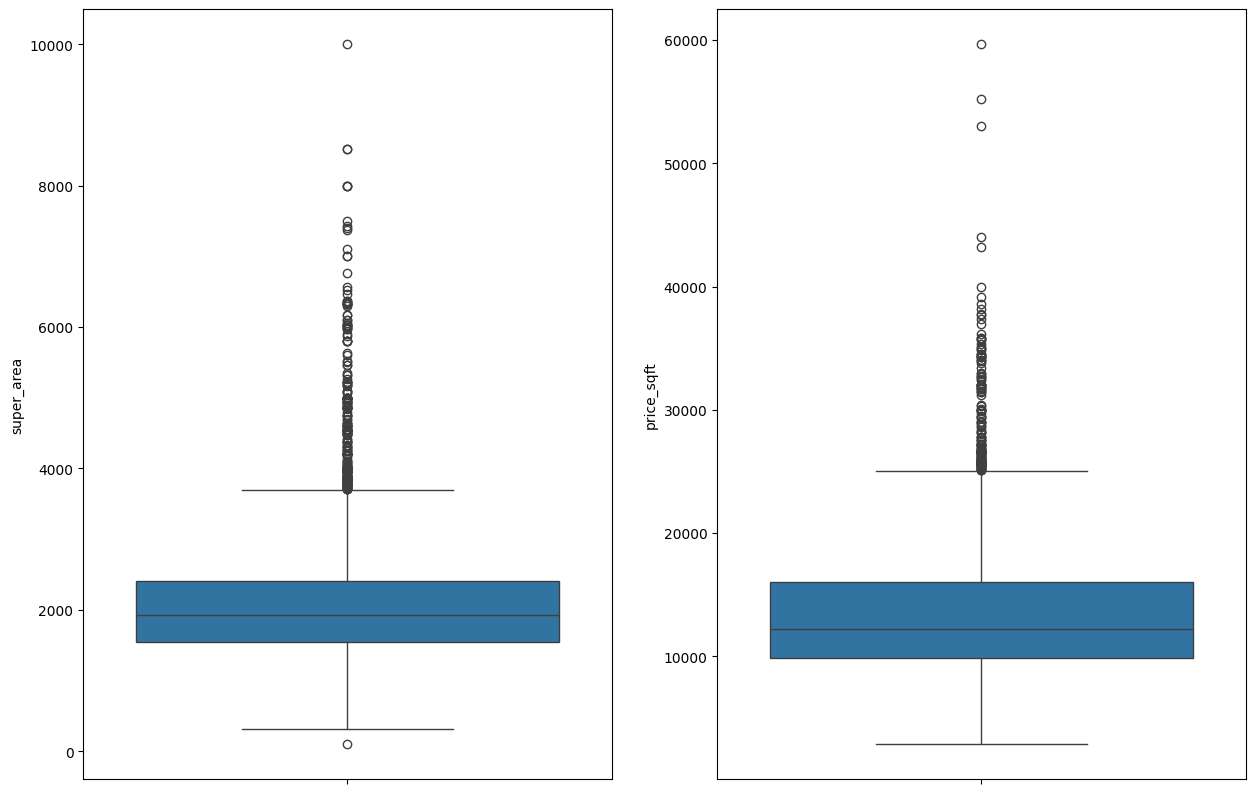

In [86]:
fig = plt.figure(figsize = (15,10))
plt.subplot(1,2,1)
sns.boxplot(data = df , y = 'super_area')

plt.subplot(1,2,2)
sns.boxplot(data = df , y = 'price_sqft')

### Cleaning sector

In [87]:
df['sector'].unique()

array(['jharsa', 'sohna', 'sector 71', 'sector 82', 'sector 89',
       'sector 86', 'sector 102', 'sector 37d', 'sector 68', 'sector 67',
       'sector 106', 'sector 63a', 'sector-33 sohna', 'sector 70',
       'sector 69', 'sector 65', 'sector 48', 'sector 37c', 'sector 81',
       'sector 95', 'sector 79', 'sector 88a', 'sector 95a', 'sector 93',
       'ardee city', 'sector 61', 'gwal pahari', 'sector 107',
       'sector 66', 'sector 92', 'sector 90', 'sector 83', 'sector 33',
       'sector 49', 'sector 14', 'sector 1a imt manesar', 'sector 54',
       'sector-2 sohna', 'sector 104', 'sector 84', 'sector 63',
       'sector 91', 'dlf phase 4', 'sector 76', 'sector 36 sohna',
       'dlf phase 5', 'sector 99', 'sector 77', 'sector 67a', 'sector 62',
       'sector 99a', 'malibu town', 'sector 105', 'golf course ext road',
       'sector 70a', 'sector 113', 'wazirabad', 'sector 108', 'sector 3',
       'nirvana country', 'old dlf colony', 'nawada fatehpur',
       'sector 109', 's

In [88]:
sector_replace = {'sohna': 'sohna',
 'sector-33 sohna': 'sohna',
 'sector-2 sohna': 'sohna',
 'sohna road': 'sohna',
 'sector 36 sohna': 'sohna',
 'sector-35 sohna': 'sohna', 
 'sector-4 sohna': 'sohna',
 'sector-5 sohna': 'sohna',
 
 'nirvana country': 'sector 50',
 'pocket h nirvana country': 'sector 50',
 
	'dlf phase 1': 'sector 28',
 's block dlf phase 3': 'sector 24',
 'dlf phase 3': 'sector 23',
 'dlf phase 4': 'sector 43',
 'dlf phase 5': 'sector 54',
 
	'sushant lok phase 1': 'sushant lok phase 1',
 'sushant lok phase 3': 'sushant lok phase 3',
 'sushant lok 2': 'sushant lok phase 2',
 'sushant lok phase 2': 'sushant lok phase 2',
 'b block sushant lok phase 1': 'sushant lok phase 1',
  
 'gwal pahari': 'gwal pahari',

 'garauli khurd': 'sector 37d',
 'heritage city': 'sector 25',
 'tikri': 'sector 48',
 'dlf phase 2': 'sector 25',
 'palam vihar': 'sector 3',
 
 
 'nawada fatehpur': 'sector 86',
 'chakkarpur': 'sector 28',
 
 
 'wazirabad': 'sector 52',
 'block c': 'sector 43',
 'garauli kalan': 'sector 37c',

 'suncity': 'sector 54',
 
 'malibu town': 'sector 47',
 'ardee city': 'sector 52',
 
 'sihi village': 'sector 84',
 'block h': 'sector 26',
 
 'dhorka': 'sector 92',
 'b1 block sector 57': 'sector 57',
 'iffco chowk': 'sector 18',

 'naurangpur': 'sector 79',
 'block s sector 49': 'sector 49',
 'jharsa': 'sector 39',
 'hayatpur': 'sector 93',
 'jawahar nagar': 'sector 12',
 'golf course ext road': 'sector 67',
 
 'old dlf colony': 'sector 14',
 
 'badha': 'sector 86',
 'palam vihar extension': 'sector 1',

 'behrampur': 'sector 71',
 
 'galleria market': 'sector 27',
 'sikandarpur badha': 'sector 85',

 'uppals southend': 'sector 49'}

In [89]:
df[df['sector']=='civil lines']['address'].unique()

array(['civil homes society\nCivil Lines, Gurgaon'], dtype=object)

In [90]:
#37D,37D
df[df['sector']=='old dlf colony']

,link,address,apartment_name,sector,price,price_sqft,super_area,bedrooms,bathroom,balcony,additional_rooms,age_possession,floor,floor_num,total_floors,furnishing_type,facing,num_parking,features,servant_room,study_room,pooja_room,store_room,luxury_score,luxury_category,parking
188,https://www.99acres.com/3-bhk-bedroom-apartmen...,"builder floor\nOld DLF Colony, Gurgaon",builder floor,old dlf colony,1.25,7042.3,1775.0,3,3,1,Others,1 to 5 year old,3rd of 4 Floors,3,4,Semifurnished,South-East,1 Covered,"['Lift(s)', 'Maintenance Staff', 'Water Storag...",0,0,0,0,9,low,1


In [91]:
df['sector'].replace(sector_replace,inplace=True)

/var/folders/s_/8psmrzpd1ljgqhthwdx4fv000000gn/T/ipykernel_38199/34098842.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sector'].replace(sector_replace,inplace=True)


In [93]:
#'civil lines','new colony','manesar'
df.drop(index = df[df['sector'].isin(['civil lines','new colony','manesar'])].index, inplace=True)

In [94]:
df.to_csv('4.3_dataset_clean_v2.csv' ,index=False)

In [95]:
import sweetviz as sv

# Create and generate the report
feature_config = sv.FeatureConfig(skip=['link','address','additional_rooms','floor', 'num_parking','features'])
report = sv.analyze(source=df, 
                    target_feat='price',
                    feat_cfg=feature_config)

# Show the report in an HTML file
report.show_html(filepath="sweetviz_report.html",
                 layout='vertical')


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


Based on your Sweetviz report, here are the **key associations** and **actionable insights** you can use to enhance your housing price prediction model:

---

### 🔗 **Top Numerical Associations with Price**
These are numerical variables that are most correlated with the target variable `price`:

| Feature         | Correlation with Price |
|----------------|------------------------|
| `super_area`   | **0.78**               |
| `price_sqft`   | 0.77                   |
| `total_floors` | 0.40                   |
| `floor_num`    | 0.26                   |
| `luxury_score` | 0.17                   |

✅ **Actionables**:
- **Keep `super_area` and `price_sqft` in your model** as primary predictors—they are the most strongly associated with price.
- You may also consider including `total_floors` and `floor_num` as they provide meaningful variance.

---

### 🏷️ **Top Categorical Associations with Price**
These show how categorical features are associated with variations in price:

| Categorical Feature  | Correlation Ratio |
|----------------------|-------------------|
| `bedrooms`           | **0.58**          |
| `bathroom`           | **0.58**          |
| `servant_room`       | 0.44              |
| `parking`            | 0.42              |
| `balcony`            | 0.28              |
| `luxury_category`    | 0.18              |

✅ **Actionables**:
- Use `bedrooms`, `bathroom`, `parking`, and `servant_room` as categorical features (or one-hot encoded) in your model—they offer significant insight into the property's price range.
- `luxury_category` could serve as a composite indicator of various amenities and affect price perception.

---

### 🧠 **Model Design Recommendations**
- 📊 Include both **numerical** (`super_area`, `price_sqft`) and **categorical** (`bedrooms`, `bathroom`, `luxury_category`) features for a **mixed-feature regression model**.
- 🔍 You can engineer new features like `price per room` or `area per room`, which might improve performance further.
- 🤖 Try tree-based models like **Random Forests or XGBoost** which can automatically handle nonlinear relationships and mixed data types.


---

## 💰 Target Variable: `price`

### **Descriptive Stats**:
- **Count**: 5,591 records
- **Min**: ₹0.3 Lakh
- **Max**: ₹27.3 Lakh
- **Mean (Avg)**: ₹2.9 Lakh
- **Median**: ₹2.4 Lakh
- **Std Dev**: ₹2.08 Lakh
- **IQR (Q3 - Q1)**: ₹1.85 Lakh

📌 **Insight**:
- Price is **right-skewed**, meaning most properties are in the lower-mid range, with **few high-end outliers** pushing up the average.

👉 **Actionable**:
- Consider **log-transforming** price in regression models to reduce skewness and improve linear model performance.
- Flag **outliers** for further domain-specific investigation or segment them (e.g. “luxury” vs “affordable” units).

---

## 📈 Top Numerical Associations with Price

| Feature        | Pearson Corr. |
|----------------|---------------|
| `super_area`   | **0.78**       |
| `price_sqft`   | **0.77**       |
| `total_floors` | 0.35           |
| `floor_num`    | 0.26           |

📌 **Insight**:
- Larger area and price per sqft are **strong predictors** of total price.
- Higher floor number slightly correlates with price, possibly indicating better views or location within the building.

👉 **Actionable**:
- Keep `super_area` and `price_sqft` as **core numerical features** in your model.
- Consider interaction terms like `super_area * price_sqft` or derived features like `price_per_floor`.

---

## 🏢 Categorical Feature Influence on Price

### Bedrooms:
| Bedrooms | % of Data | Avg Price (Lakh ₹) |
|----------|------------|--------------------|
| 3        | 37%        | ₹3.45              |
| 2        | 22%        | ₹2.36              |
| 4        | 19%        | ₹4.71              |
| 1        | 7%         | ₹1.40              |

📌 **Insight**:
- Average price **increases with bedrooms**.
- Properties with 4+ bedrooms form a **premium cluster**.

👉 **Actionable**:
- Use `bedrooms` as a **category**, and **bin** larger homes as “Luxury” (e.g., 4+ bedrooms).
- Try model segmentation: one model for 1–2 BHK, another for 3–5 BHK homes.

---

### Bathrooms & Parking:
- Each additional bathroom generally increases average price.
- Properties with more parking spots also correlate with higher price.

👉 **Actionable**:
- Treat `bathroom` and `parking` as **ordinal features** or include them in a `luxury_score`.

---

## 🧱 Room Type Features

Features like `pooja_room`, `servant_room`, `store_room`, `study_room`:
- **Low individual correlation** with price (0.01–0.04).
- But **presence of multiple extra rooms** signals **luxury or larger homes**.

👉 **Actionable**:
- Combine these into a new feature like `extra_room_count`.
- Can be used to segment high-end listings or add to a composite `luxury_score`.

---

## 🏠 Sector / Location-Based Insight

While the report doesn't show geospatial plots, the **sector/locality** variable (e.g., “Sector 49”, “DLF Phase 2”) can have **massive price variance**.

👉 **Actionable**:
- Encode `sector` as a categorical variable.
- Alternatively, calculate **average sector price per sqft** and use that as a contextual pricing benchmark feature.

---

## 🧠 Feature Engineering Opportunities

| New Feature              | Based on                   | Purpose                                      |
|--------------------------|----------------------------|----------------------------------------------|
| `log_price`              | log(price)                 | Normalize skewness                           |
| `luxury_score`           | rooms + amenities          | Capture upper-segment trends                 |
| `price_per_room`         | price / (bed + bath + extra) | Efficiency metric                           |
| `price_per_sqft_zscore`  | price_sqft vs sector avg   | Price anomaly detection                      |